In [2]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import os
import ast

# For the animated chart
from matplotlib.animation import FuncAnimation

# To display the animated chart in the notebook.
from IPython.display import HTML

from patsy import dmatrices  
import statsmodels.api as sm    
import statsmodels.formula.api as smf  


## Task 3 ##

Task 3 is arranged according to the following steps:
1) Clean all of our data, taking relevant quantities and price.
2) Determine what should be classed as a 'block order', with a discussion of expected order size.
3) Scan through data to find these block orders.
4) Illustrate how mid vs micro can be used to estimate market impact, and determine the length of time we shall use.
5) Plot orders in a panel regression, with order size and price shift.
6) Refine regression, adding new control variables.
7) Discussion of other approaches.

### Data Cleaning ###

I have taken a new approach to capturing bid/asks in the LOB vs Task 2. Our traders from the simulated LOB data have several unique features, that simplify finding block orders. Firstly, new orders will be the most competitive, and therefore be at the top of the LOB. So by only capturing those at the top of LOB we can use our processing much more efficiently, as we will capture all new block orders.

Therefore, while we need to process all of the data available, we only require the highest bid/ask price & quantity, therefore, using the ast library, I will turn the bid/asks into a list and only extract the top quantities and prices, rather than turning every LOB into a dataframe.

To be efficient, we shall begin by applying this function to all of the files in our dataset, and store the results in a dictionary.

In [ ]:
# Import function that uses AST library to save each LOB string as a list object, and take the top ask/bid quantity and prices.
from f_t3_functions import t3_func

# Import function that will apply this to a series of CSV files.
from f_t3_functions import t3_lob_files

In [ ]:
os.chdir('/Users/robertnoble/Library/CloudStorage/OneDrive-UniversityofBristol/EWDS/EWPY/Assessment/DataSet01')

# Run out functions on all files.
file_list = ['UoB_Set01_2024-01-02LOBs.csv', 'UoB_Set01_2024-01-03LOBs.csv', 'UoB_Set01_2024-01-04LOBs.csv', 'UoB_Set01_2024-01-05LOBs.csv', 'UoB_Set01_2024-01-08LOBs.csv', 'UoB_Set01_2024-01-09LOBs.csv', 'UoB_Set01_2024-01-10LOBs.csv', 'UoB_Set01_2024-01-11LOBs.csv', 'UoB_Set01_2024-01-12LOBs.csv', 'UoB_Set01_2024-01-15LOBs.csv', 'UoB_Set01_2024-01-16LOBs.csv', 'UoB_Set01_2024-01-17LOBs.csv', 'UoB_Set01_2024-01-18LOBs.csv', 'UoB_Set01_2024-01-19LOBs.csv', 'UoB_Set01_2024-01-22LOBs.csv', 'UoB_Set01_2024-01-23LOBs.csv', 'UoB_Set01_2024-01-24LOBs.csv', 'UoB_Set01_2024-01-25LOBs.csv', 'UoB_Set01_2024-01-26LOBs.csv', 'UoB_Set01_2024-01-29LOBs.csv', 'UoB_Set01_2024-01-30LOBs.csv', 'UoB_Set01_2024-01-31LOBs.csv', 'UoB_Set01_2024-02-01LOBs.csv', 'UoB_Set01_2024-02-02LOBs.csv', 'UoB_Set01_2024-02-05LOBs.csv', 'UoB_Set01_2024-02-06LOBs.csv', 'UoB_Set01_2024-02-07LOBs.csv', 'UoB_Set01_2024-02-08LOBs.csv', 'UoB_Set01_2024-02-09LOBs.csv', 'UoB_Set01_2024-02-12LOBs.csv', 'UoB_Set01_2024-02-13LOBs.csv', 'UoB_Set01_2024-02-14LOBs.csv', 'UoB_Set01_2024-02-15LOBs.csv', 'UoB_Set01_2024-02-16LOBs.csv', 'UoB_Set01_2024-02-19LOBs.csv', 'UoB_Set01_2024-02-20LOBs.csv', 'UoB_Set01_2024-02-21LOBs.csv', 'UoB_Set01_2024-02-22LOBs.csv', 'UoB_Set01_2024-02-23LOBs.csv', 'UoB_Set01_2024-02-26LOBs.csv', 'UoB_Set01_2024-02-27LOBs.csv', 'UoB_Set01_2024-02-28LOBs.csv', 'UoB_Set01_2024-02-29LOBs.csv', 'UoB_Set01_2024-03-01LOBs.csv', 'UoB_Set01_2024-03-04LOBs.csv', 'UoB_Set01_2024-03-05LOBs.csv', 'UoB_Set01_2024-03-06LOBs.csv', 'UoB_Set01_2024-03-07LOBs.csv', 'UoB_Set01_2024-03-08LOBs.csv', 'UoB_Set01_2024-03-11LOBs.csv', 'UoB_Set01_2024-03-12LOBs.csv', 'UoB_Set01_2024-03-13LOBs.csv', 'UoB_Set01_2024-03-14LOBs.csv', 'UoB_Set01_2024-03-15LOBs.csv', 'UoB_Set01_2024-03-18LOBs.csv', 'UoB_Set01_2024-03-19LOBs.csv', 'UoB_Set01_2024-03-20LOBs.csv', 'UoB_Set01_2024-03-21LOBs.csv', 'UoB_Set01_2024-03-22LOBs.csv', 'UoB_Set01_2024-03-25LOBs.csv', 'UoB_Set01_2024-03-26LOBs.csv', 'UoB_Set01_2024-03-27LOBs.csv', 'UoB_Set01_2024-03-28LOBs.csv', 'UoB_Set01_2024-04-02LOBs.csv', 'UoB_Set01_2024-04-03LOBs.csv', 'UoB_Set01_2024-04-04LOBs.csv', 'UoB_Set01_2024-04-05LOBs.csv', 'UoB_Set01_2024-04-08LOBs.csv', 'UoB_Set01_2024-04-09LOBs.csv', 'UoB_Set01_2024-04-10LOBs.csv', 'UoB_Set01_2024-04-11LOBs.csv', 'UoB_Set01_2024-04-12LOBs.csv', 'UoB_Set01_2024-04-15LOBs.csv', 'UoB_Set01_2024-04-16LOBs.csv', 'UoB_Set01_2024-04-17LOBs.csv', 'UoB_Set01_2024-04-18LOBs.csv', 'UoB_Set01_2024-04-19LOBs.csv', 'UoB_Set01_2024-04-22LOBs.csv', 'UoB_Set01_2024-04-23LOBs.csv', 'UoB_Set01_2024-04-24LOBs.csv', 'UoB_Set01_2024-04-25LOBs.csv', 'UoB_Set01_2024-04-26LOBs.csv', 'UoB_Set01_2024-04-29LOBs.csv', 'UoB_Set01_2024-04-30LOBs.csv', 'UoB_Set01_2024-05-01LOBs.csv', 'UoB_Set01_2024-05-02LOBs.csv', 'UoB_Set01_2024-05-03LOBs.csv', 'UoB_Set01_2024-05-07LOBs.csv', 'UoB_Set01_2024-05-08LOBs.csv', 'UoB_Set01_2024-05-09LOBs.csv', 'UoB_Set01_2024-05-10LOBs.csv', 'UoB_Set01_2024-05-13LOBs.csv', 'UoB_Set01_2024-05-14LOBs.csv', 'UoB_Set01_2024-05-15LOBs.csv', 'UoB_Set01_2024-05-16LOBs.csv', 'UoB_Set01_2024-05-17LOBs.csv', 'UoB_Set01_2024-05-20LOBs.csv', 'UoB_Set01_2024-05-21LOBs.csv', 'UoB_Set01_2024-05-22LOBs.csv', 'UoB_Set01_2024-05-23LOBs.csv', 'UoB_Set01_2024-05-24LOBs.csv', 'UoB_Set01_2024-05-28LOBs.csv', 'UoB_Set01_2024-05-29LOBs.csv', 'UoB_Set01_2024-05-30LOBs.csv', 'UoB_Set01_2024-05-31LOBs.csv', 'UoB_Set01_2024-06-03LOBs.csv', 'UoB_Set01_2024-06-04LOBs.csv', 'UoB_Set01_2024-06-05LOBs.csv', 'UoB_Set01_2024-06-06LOBs.csv', 'UoB_Set01_2024-06-07LOBs.csv', 'UoB_Set01_2024-06-10LOBs.csv', 'UoB_Set01_2024-06-11LOBs.csv', 'UoB_Set01_2024-06-12LOBs.csv', 'UoB_Set01_2024-06-13LOBs.csv', 'UoB_Set01_2024-06-14LOBs.csv', 'UoB_Set01_2024-06-17LOBs.csv', 'UoB_Set01_2024-06-18LOBs.csv', 'UoB_Set01_2024-06-19LOBs.csv', 'UoB_Set01_2024-06-20LOBs.csv', 'UoB_Set01_2024-06-21LOBs.csv', 'UoB_Set01_2024-06-24LOBs.csv', 'UoB_Set01_2024-06-25LOBs.csv', 'UoB_Set01_2024-06-26LOBs.csv', 'UoB_Set01_2024-06-27LOBs.csv', 'UoB_Set01_2024-06-28LOBs.csv']

# Warning: this can be a lengthy operation, as we are cleaning all of the data.
t3_cleaned_data = t3_lob_files(file_list)

### Block Orders & Market Impact ###

The next challenge of Task 3 is to identify instances of *market impact*, where a large order causes a shift in prices on the counterparty side, before any transaction takes place. 

There is no clear rule as to what constitutes a large or 'block' order. In a frequently traded and large market, such as US Treasury bills, for a block order to have market impact it will need to be many times larger than a block order in a smaller and less liquid market. Therefore, the size of the order relative to the existing trading pool is more important than the absolute size of the order.

As liquidity reflects the degree to which buying or selling affects the price, it can serve as a helpful proxy of the likelihood of a 'block' order having market impact. Using Schroeter's (2014) measure of LOB liquidity as the spread between the best bid and ask price, we can visualise how much liquidity varies between and within days.

It should be noted, however, that liquidity is not exogenenous to block orders, indeed as we will see, changing liquidity is exactly what we would expect as part of market impact.

In [ ]:
os.chdir('/Users/robertnoble/Library/CloudStorage/OneDrive-UniversityofBristol/EWDS/EWPY/Assessment')

# First, import function that outputs the best bid/ask prices from a string and calulcates the spread between them.
from f_t3_functions import t3_spread

# Next, import a function that applies the spread function to a LOB CSV file.
from f_t3_functions import t3_spread_lob_files

# As we want to show there is variation, we illustrate our point by taking 3 random files from the directory.
os.chdir('/Users/robertnoble/Library/CloudStorage/OneDrive-UniversityofBristol/EWDS/EWPY/Assessment/DataSet01')

file_list = ['UoB_Set01_2024-01-02LOBs.csv', 'UoB_Set01_2024-01-03LOBs.csv', 'UoB_Set01_2024-01-04LOBs.csv', 'UoB_Set01_2024-01-05LOBs.csv'] 

t3_spreads = t3_spread_lob_files(file_list)

In [ ]:
check = (t3_cleaned_data['UoB_Set01_2024-01-02LOBs.csv'])

print(check)

In [ ]:
from f_t3_block_finder import t3_block_finder    

In [ ]:
block_data = t3_block_finder(t3_cleaned_data)


In [ ]:
check = (block_data['UoB_Set01_2024-01-25LOBs.csv'])

print(check)

In [ ]:
# Create an empty list to store the results
result = []

# Iterate over the items in block_data dictionary
for filename, df in block_data.items():
    # Get the number of observations (rows) in the dataframe
    num_observations = len(df)
    # Append the filename and number of observations to the result list
    result.append({'filename': filename, 'number of observations': num_observations})

# Create a dataframe from the result list
result_df = pd.DataFrame(result)

# Print the resulting dataframe
print(result_df)


In [ ]:
import seaborn as sns
# Create a histogram of the number of observations
plt.hist(result_df['number of observations'], bins=10, density=True)
sns.kdeplot(result_df['number of observations'])
plt.xlabel('Number of Observations')
plt.ylabel('Density')
plt.title('Number of Block Orders')
plt.show()


### Market Impact Time ###

As market impact is defined as prices moving away from those desired by the block order issuer, before a transaction takes place. We can logically conclude two things about our time range: 
(1) Firstly, it should not include any transactions, if it does, then by definition we are no longer solely recording market impact. 
(2) Secondly, again by definition, we are only interested in price movement away from the price desired by the block order issuer. If there is a block bid order, and prices initially rise, as ask orders reformulate, before then falling, we are only interested in the initial rise. 

Therefore, we can measure the required time by the continued movement of the 'mid-price', until it reverses its course. As we have seen, it will follow the path predicted by the mid-price, so the spread between the mid and micro prices should fall during the market impact. 

If the gap widens again, either the mid price has reversed course or the micro-price has again shifted, in which case we are no longer purely observing the impact of the block order on counterparty prices, but indeed on other possible quantity movements.

Therefore, we will look at how long after a block order it takes for the mid/micro spread to narrow as far as it will go.

In [ ]:
for key, df in t3_cleaned_data.items():
    # Initial block condition: Orders must be greater than 1
    initial_block_condition = (df['ask_quantity'] > 1) & (df['bid_quantity'] > 1)

    # Additional block conditions: At least 10x the counterparty size, and bigger than the previous order on its side of the LOB
    additional_block_condition = ((df['bid_quantity'] >= 10 * df['ask_quantity']) & (df['bid_quantity'] > df['bid_quantity'].shift(1))) | \
                                 ((df['ask_quantity'] >= 10 * df['bid_quantity']) & (df['ask_quantity'] > df['ask_quantity'].shift(1)))

    # Combined block order condition
    block_order_condition = initial_block_condition & additional_block_condition

    # Create 'block order' column with 1 if true, 0 otherwise
    df['block_order'] = 0  # Default to 0
    df.loc[block_order_condition, 'block_order'] = 1  # Set to 1 where block order conditions are met

    # Update the dataframe in the original dictionary
    t3_cleaned_data[key] = df

# The 't3_cleaned_data' dictionary is now updated with the 'block order' column.




In [ ]:
checkycheck = t3_cleaned_data['UoB_Set01_2024-01-02LOBs.csv']

In [ ]:
# Mid/micro calculation

for key, df in t3_cleaned_data.items():
    # Mid price calculation 
    df['mid'] = (df['ask_price'] + df['bid_price'])/2

    # Micro price calculation 
    total_quantity = (df['ask_quantity'] + df['bid_quantity'])
    df['micro'] = (df['bid_price'] * df['ask_quantity'] + df['ask_price'] * df['bid_quantity']) / total_quantity

    # This will generate n/a values, replace with 0s
    df.fillna(0, inplace=True)


    # Take absolute value of spread, so we can compare 
    df['mid_micro_spread'] = abs(df['mid'] - df['micro'])

    # If spread narrows, assign a 1. We will multiply this by seconds to calculate average time.
    df['spread_change'] = (df['mid_micro_spread'] - df['mid_micro_spread'].shift(1) < 0).astype(int)

    # Update the dataframe in the original dictionary
    t3_cleaned_data[key] = df





In [ ]:
checkycheckmid = t3_cleaned_data['UoB_Set01_2024-01-02LOBs.csv']
checkycheckmid.head()

In [ ]:
block_times = {}

for key, df in t3_cleaned_data.items():
    # Calculate the spread before the block order
    df['pre_block_spread'] = df['mid_micro_spread'].shift(1)

    # Iterate over the DataFrame to find the seconds until the spread is no longer less than or equal to the block spread
    for i in df[df['block_order'] == 1].index:
        start_time = df.loc[i, 'time']
        block_spread = df.loc[i, 'pre_block_spread']
        # Initialize with the maximum time difference
        df.loc[i, 'seconds_after_block'] = df['time'].iloc[-1] - start_time

        for j in range(i + 1, len(df)):
            # Check if the spread is greater than the pre-block spread, indicating it is not narrowing anymore
            if df.loc[j, 'mid_micro_spread'] <= block_spread:
                end_time = df.loc[j, 'time']
                df.loc[i, 'seconds_after_block'] = end_time - start_time
                counterparty_price = df.loc[j, 'ask_price'] if df.loc[i, 'ask_quantity'] < df.loc[i, 'bid_quantity'] else df.loc[j, 'bid_price']
                df.loc[i, 'counterparty_price'] = counterparty_price
                break

    # Counterparty price change. As this is conditional we will use np.where
    df['counterparty_price_change'] = np.where(
        df['bid_quantity'] < df['ask_quantity'],
        abs(df['bid_price'] - df['counterparty_price']),
        abs(df['ask_price'] - df['counterparty_price'])
    )

    # Specify quantity size of block order
    df['block_order_size'] = np.where(
        df['bid_quantity'] < df['ask_quantity'],
        df['ask_quantity'],
        df['bid_quantity'])
    
    # Specify counter party order size
    df['cp_order_size'] = np.where(
        df['bid_quantity'] > df['ask_quantity'],
        df['ask_quantity'],
        df['bid_quantity'])
    
    # Specify counter party price
    df['cp_initial_price'] = np.where(
        df['bid_quantity'] > df['ask_quantity'],
        df['ask_price'],
        df['bid_price'])


    # Extract the rows where 'block_order' is 1 and there is a valid 'seconds_after_block'
    block_times[key] = df[(df['block_order'] == 1)].copy()
    


In [ ]:

# Create the scatter plot
plt.scatter(regression_df['block_order_size'], (regression_df['counterparty_price_change']/regression_df['cp_initial_price']))

# # Calculate the coefficients of the polynomial that best fits the data
# coefficients = np.polyfit(regression_df['block_order_size'], regression_df['counterparty_price_change'], 1)

# # Create the line of best fit using the coefficients
# line_of_best_fit = np.polyval(coefficients, regression_df['block_order_size'])

# # Plot the line of best fit
# plt.plot(regression_df['block_order_size'], line_of_best_fit, color='red')

# Set the x-axis label
plt.xlabel('Block Order Size')

# Set the y-axis label
plt.ylabel('Counterparty Price Change')

# Set the title
plt.title('Scatter Plot of Counterparty Price Change vs Block Order Size')

# Set the y-axis limit to 100
plt.ylim(0, .25)

# Show the plot
plt.show()


In [ ]:
# Begin with very basic OLS using chart above:

y, X = dmatrices('counterparty_price_change ~ block_order_size', data=regression_df, return_type='dataframe')

model1 = sm.OLS(y, X)
est1_OLS = model1.fit(cov_type="HC0")
print(est1_OLS.summary())

In [ ]:
# Add other values for regression

# Natural log of price change
regression_df['counterparty_price_change_log'] = np.log(regression_df['counterparty_price_change'])

# Natural log of block order size
regression_df['block_order_size_log'] = np.log(regression_df['block_order_size'])

# Spread of bid/ask as liquidity proxy
regression_df['liquidity_spread'] = (regression_df['ask_price'] - regression_df['bid_price'])

# Relative size of block vs counterparty
regression_df['relative_block_size'] = (regression_df['block_order_size']/regression_df['cp_order_size'])

# Relative size of counterparty price change vs original counterparty price
regression_df['price_change_magnitude'] = (regression_df['counterparty_price_change']/regression_df['cp_initial_price'])

In [ ]:

y, X = dmatrices('price_change ~ block_order_size + liquidity_spread', data=regression_df, return_type='dataframe')

# y, X = dmatrices('counterparty_price_change ~ relative_block_size + liquidity_spread', data=regression_df, return_type='dataframe')


model2 = sm.OLS(y, X)
est2_OLS = model2.fit(cov_type="HC0")
print(est2_OLS.summary())



In [ ]:
import numpy as np
# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create a list to store the data for the histogram
data = []

# Iterate over the block_times dictionary and append the seconds_after_block values to the data list
for key, df in block_times.items():
    data.extend(df['seconds_after_block'])

# Create the histogram using the data list
ax.hist(data, bins=500)

# Set the x-axis label
ax.set_xlabel('Seconds After Block')

# Set the y-axis label
ax.set_ylabel('Frequency')

# Set the title
ax.set_title('Histogram of Seconds After Block for All Block Orders')

# Calculate the mean and median values
mean_value = np.mean(data)
median_value = np.median(data)

# Print the mean and median values
print("Mean:", mean_value)
print("Median:", median_value)

# Show the plot
plt.show()


## Regression ## 

Let's begin by plotting counterparty price change, for our desired time range, and block size (for those that meet our criteria.)

In [ ]:

import matplotlib.pyplot as plt

# Create a figure with 4 subplots, sharing the Y-axis
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

# Iterate over the result_dfs dictionary and plot each dataframe
for i, (fname, df) in enumerate(t3_spreads.items()):
    # Plot the price vs. time with translucent points
    axs[i].scatter(df['time'], df['spread'], s=1, alpha=0.1)
    axs[i].set_title(fname)
    axs[i].set_xlabel('Time (seconds)')
    axs[i].set_ylabel('Bid/Ask Spread')
    axs[i].set_ylim(0, 850)

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plots
plt.show()


This helps to explain wide fluctations in the quantities of the best bid and ask offers:

In [ ]:
os.chdir('/Users/robertnoble/Library/CloudStorage/OneDrive-UniversityofBristol/EWDS/EWPY/Assessment')

# First, import function that outputs th quantities of the best bid/ask prices from a string.
from f_t3_functions import t3_quantities

# Next, import a function that applies the quantity function to a LOB CSV file.
from f_t3_functions import t3_qs_lob_files

# As we want to show there is variation, we illustrate our point by taking 3 random files from the directory.
os.chdir('/Users/robertnoble/Library/CloudStorage/OneDrive-UniversityofBristol/EWDS/EWPY/Assessment/DataSet01')

file_list = ['UoB_Set01_2024-01-02LOBs.csv', 'UoB_Set01_2024-01-03LOBs.csv', 'UoB_Set01_2024-01-04LOBs.csv', 'UoB_Set01_2024-01-05LOBs.csv'] # Replace with actual file names

quantity_dfs = t3_qs_lob_files(file_list)

In [ ]:
# Create a figure with 4 subplots for bid sizes
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
# Iterate over the result_dfs dictionary and plot each dataframe
for i, (fname, df) in enumerate(result_dfs.items()):
    # Plot the boxplot of bid sizes
    axs[i].plot(df['time'], df['bid_quantity'], label = 'Bid Quantity')
    axs[i].plot(df['time'], df['ask_quantity'], label = 'Ask Quantity')
    axs[i].set_title(fname)
    axs[i].set_xlabel('Quantities')
    axs[i].set_ylabel('Bid Size')
    axs[i].legend()
    axs[i].set_ylim(0,70)

# Adjust the spacing between subplots
plt.tight_layout()

# Show the bid size plots
plt.show()

We can clearly see both high variations in liquidity and order size. Therefore, we will not use an absolute measure of a block order, as this may not be sufficiently large when the market is liquid, or capture smaller block orders when the market is illiquid. Instead, we shall identify block orders in terms of size versus the highest counterparty offer, as a mismatch between supply and demand is what will lead to market impact. 

Church & Cliff (2019) (henceforth denoted by CG-19) reference a factor of 10 or more, for an orders quantity, verus the quantity of the best counterparty, as sufficient for a block order. Whilst we will adopt this rule, we will further refine this assumption for our data. Firstly, we require the counterparty order size to be greater than 1. Without this assumption, we will capture (i) instances where an order appears as a block order just because there are no counterparty orders, even if it is relatively small, and (ii) so we ensure we do not capture orders that are not normally unusual (those around 10-15), but appear large because the counterparty is only 1. Secondly, we only accept an order to be a 'block order' if it is larger than the previous largest order on its side of the offer book. Intuitively, if we are trying to capture the initial block order, we expect it to be larger than the previous order.

The function below works to identify any LOB times where these three conditions are found. 

In [ ]:
# Create a figure with 4 subplots for bid sizes
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
# Iterate over the result_dfs dictionary and plot each dataframe
for i, (fname, df) in enumerate(block_orders.items()):
    # Plot the boxplot of bid sizes
    axs[i].scatter(df['time'], df['bid_quantity'], label = 'Bid Quantity')
    axs[i].scatter(df['time'], df['ask_quantity'], label = 'Ask Quantity')
    axs[i].set_title(fname)
    axs[i].set_xlabel('Quantities')
    axs[i].set_ylabel('Bid Size')
    axs[i].legend()
    axs[i].set_ylim(0,70)

# Adjust the spacing between subplots
plt.tight_layout()

# Show the bid size plots
plt.show()

As shown in CG-19, we can use mid and micro prices to identify block trades which will have a market impact. This is possible because (i) new bids will always move to the front of the LOB (so any block order will appear in the mid & micro prices), and (ii), traders will only seek to submit orders that are priced only 1 away from existing orders (so we shouldn't see any big jumps in micro prices unless from quantities). 

To illustrate this, we can use a similar chart to Task 2 to expand on Figure 2 from CG-19.

In [3]:
from EWPY.Assessment.z_f_calculate_mid_micro import calculate_micro_price
from EWPY.Assessment.z_f_calculate_mid_micro import calculate_mid_price

In [5]:
# Create the dataframe
initial_equilibrium = pd.DataFrame({
    'bid_price': [100, 99, 98, 97, 96, 95, 94],
    'bid_quantity': [1] * 7,
    'ask_price': [200, 201, 202, 203, 204, 205, 206],
    'ask_quantity': [1] * 7
})

demand_shift = pd.DataFrame({
    'bid_price': [100, 99, 98, 97, 96, 95, 94],
    'bid_quantity': [100, 1, 1, 1, 1, 1, 1],
    'ask_price': [200, 201, 202, 203, 204, 205, 206],
    'ask_quantity': [10, 1, 1, 1, 1, 1, 1]
})

supply_shift = pd.DataFrame({
    'bid_price': [100, 99, 98, 97, 96, 95, 94],
    'bid_quantity': [1] * 7,
    'ask_price': [200, 201, 202, 203, 204, 205, 206],
    'ask_quantity': [10, 1, 1, 1, 1, 1, 1]
})

# put all 3 into dictionary 
equilibrium_dict = {'Initial Equilibrium': initial_equilibrium, 
                   'Shift in Demand': demand_shift, 
                   'Shift in Supply': supply_shift}



ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

Error in callback <function _draw_all_if_interactive at 0x144c18400> (for post_execute):


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

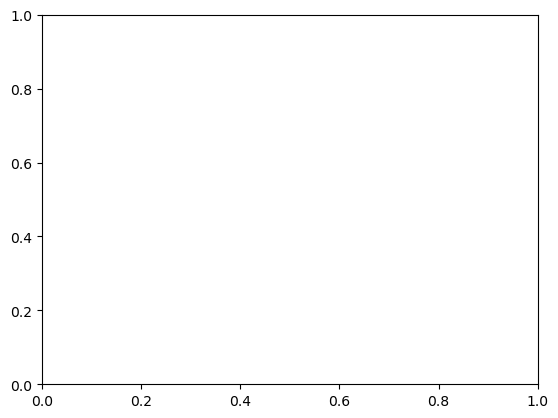

In [6]:

times = list(equilibrium_dict.keys())

fig, ax = plt.subplots()

def animate(i):
    ax.clear()  # Clear the axis to redraw
    
    # Extract the current time point data
    current_key = times[i]
    current_data = equilibrium_dict[current_key]

    # Use our custom function to adjust row lengths & N/A values from chart 1.
    # current_data = chart_data(current_data)
    
    # Calculate mid and micro prices
    mid_price = calculate_mid_price(current_data['bid_price'], 
                                    current_data['ask_price'])
    micro_price = calculate_micro_price(current_data['bid_price'], 
                                        current_data['bid_quantity'],
                                        current_data['ask_price'], 
                                        current_data['ask_quantity'])
    
    # So that both bid/ask start at 0 quantities, we add a new 0 quantity row at the highest price.
    current_data = pd.concat([
        pd.DataFrame({'bid_price': current_data.iloc[0]['bid_price'], 'bid_quantity': 0, 
                    'ask_price': current_data.iloc[0]['ask_price'], 'ask_quantity': 0}, index=[0]),
        current_data
    ], ignore_index=True)
    
    # Create step plots for bid and ask data
    ax.step(current_data['bid_quantity'].cumsum(), current_data['bid_price'], where='post', label='Demand', color='blue')
    ax.step(current_data['ask_quantity'].cumsum(), current_data['ask_price'], where='post', label='Supply', color='orange')
    
    # Plot mid and micro prices
    if not np.isnan(mid_price):
        ax.axhline(y=mid_price, color='green', linestyle='-', linewidth=2, label='Mid Price')
    if not np.isnan(micro_price):
        ax.axhline(y=micro_price, color='purple', linestyle='--', linewidth=2, label='Micro Price')

    # Add titles and labels
    ax.set_title(f'{current_key}')
    ax.set_xlabel('Quantity')
    ax.set_ylabel('Price')
    ax.legend()

    ax.set_ylim(50, 250)
    ax.set_xlim(0, 15)

# Create the animation, one frame for each time point in the dictionary. Slowed down as there are only 3 frames.
ani = FuncAnimation(fig, animate, frames=len(times), repeat=False, interval = 1000)

# Display animation:
HTML(ani.to_jshtml())



Here, we can see that a block order causes the micro-price to change, and not the mid-price. Therefore, we can visualise differences between mid and micro prices as instances of an imbalance between demand and supply, possibly from a block order, shown below for our data. 

However, it should be noted, in some instances, a mismatch between supply and demand is purely caused by a lack of liquidity, which is not a *sufficient* condition for the presence of a block order.  

In [ ]:
# Pick a block order and show the impact with animated chart.


This spread is a useful predictor of market impact. The movement of the micro-price in a direction that is unfavourable to the block trader, is exactly how we expect the counterparty to react. Subsequently, we as the mid-price changes in response, it will move closer to the micro-price. As it moves back to within a normal band with the mid-price, we can expect demand and supply to rebalance. Therefore, we shall use the spread to indicate whether there is a supply or demand imbalance. 

In [ ]:
# Spread of micro vs mid.


The time it takes to rebalance is what we will use to estimate our time-lag for a subsequent price shift. On average, it takes x seconds for the spread to return to the average band.

Now we have defined the time period, we can plot the resulting price shift with the block orders, to see what impact the block orders have on the price. As the size of the block orders are defined relative to the market conditions, we cannot 

Regression specification:

change in price = A + B0*OrderSize + B1*CounterPartySize + B2*T-1Size + B3*Spread + e 